In [1]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.data_processing import load_dataset, get_features_and_targets
from src.training import train_final_models
from src.prediction import make_row, sweep, ratio
from src.visualisation import plot_parameter_sweep


In [2]:
# Importing important libraries

print("All libraries loaded...")


All libraries loaded...


In [3]:
# Training final Gaussian Process models using src function
df = load_dataset()
X_encoded, y_stress, y_deflection = get_features_and_targets(df)

# We train using our new model_type="gaussian_process" to get smooth interpolation
stress_model, deflection_model = train_final_models(X_encoded, y_stress, y_deflection, model_type="gaussian_process")

print("GP models trained successfully on entire dataset for design sweeps!")


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 28 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 31 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 23 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GP models trained successfully on entire dataset for design sweeps!


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

In [4]:
# Sweep helper functions
print("Sweep functions ready")


Sweep functions ready


## 1. Blade Length
We run a high-resolution sweep (50 points) between 0.8m and 1.6m to demonstrate GPR's continuous interpolation capability, in contrast to the step-wise behavior of tree-based models.


In [5]:
# Sweep - Blade Length (chord=150mm, material=Carbon fiber, load=1000Pa)
# Using a dense space (50 points) for plotting a smooth curve!
blade_lengths_dense = np.linspace(0.8, 1.6, 50)
fixed1 = {"blade_length": None, "chord": 150, "material": "Carbon fiber", "load": 1000}

s1_stress, s1_defl = sweep(stress_model, deflection_model, X_encoded.columns, "blade_length", blade_lengths_dense, fixed1)

print("Continuous sweep prepared. Min predicted stress:", np.round(s1_stress.min()/1e6, 3), "MPa, Max:", np.round(s1_stress.max()/1e6, 3), "MPa")


Continuous sweep prepared. Min predicted stress: 8.603 MPa, Max: 34.558 MPa


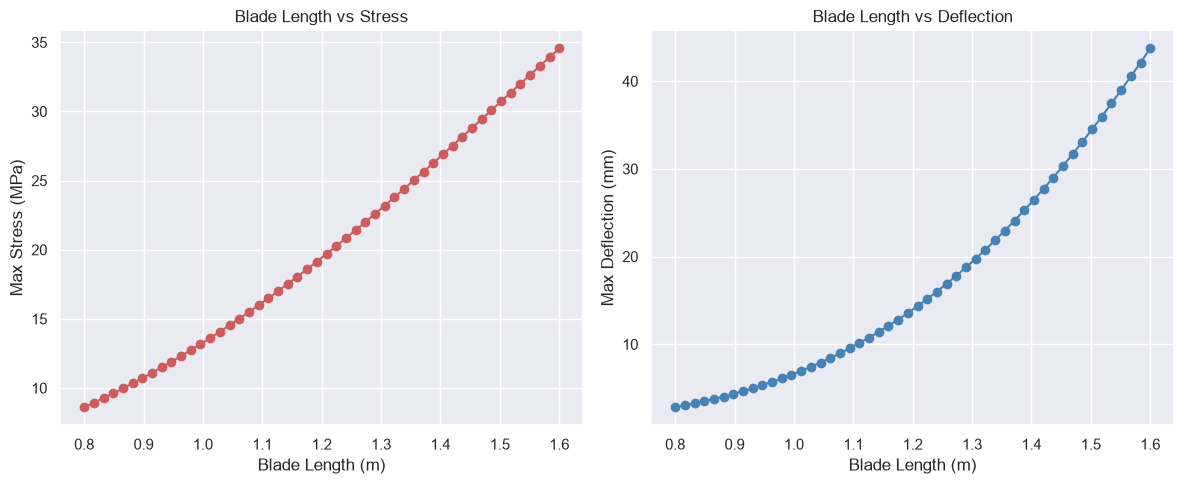

In [6]:
# Plot - Blade Length vs Stress and Deflection using src visualization
plot_parameter_sweep(
    blade_lengths_dense, s1_stress / 1e6, s1_defl * 1000,
    xlabel="Blade Length (m)",
    title_prefix="Blade Length"
)
plt.show()


## 2. Chord Length
We sweep Root Chord continuously from 150mm to 300mm.


In [7]:
# Sweep - Chord Length (blade=1.2m, material=Carbon fiber, load=1000Pa)
chords_dense = np.linspace(150, 300, 50)
fixed2 = {"blade_length": 1.2, "chord": None, "material": "Carbon fiber", "load": 1000}

s2_stress, s2_defl = sweep(stress_model, deflection_model, X_encoded.columns, "chord", chords_dense, fixed2)

print("Continuous sweep prepared. Min predicted deflection:", np.round(s2_defl.min()*1000, 3), "mm, Max:", np.round(s2_defl.max()*1000, 3), "mm")


Continuous sweep prepared. Min predicted deflection: 1.877 mm, Max: 13.953 mm


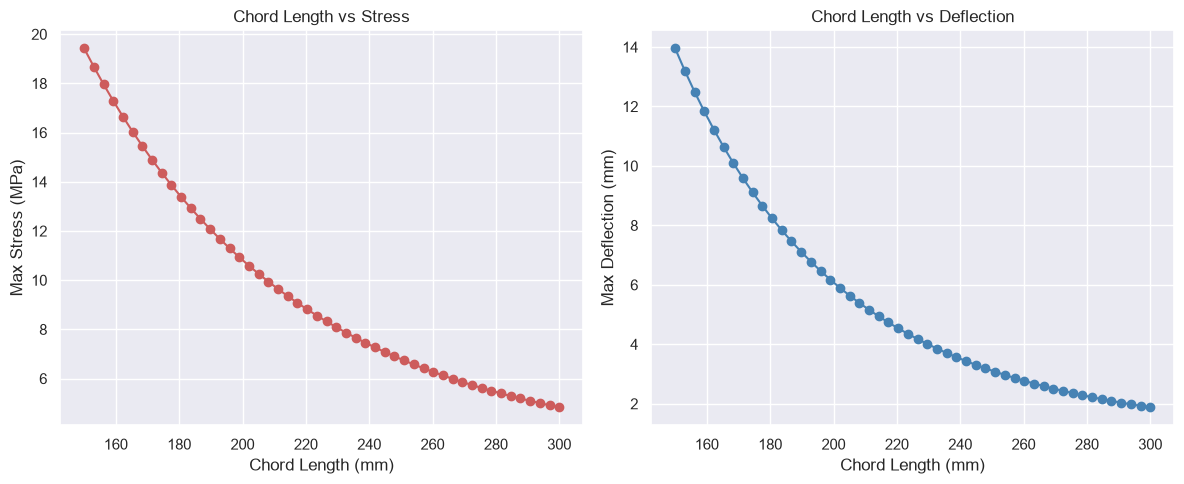

In [8]:
# Plot - Chord Length vs Stress and Deflection using src visualization
plot_parameter_sweep(
    chords_dense, s2_stress / 1e6, s2_defl * 1000,
    xlabel="Chord Length (mm)",
    title_prefix="Chord Length"
)
plt.show()


## 3. Load
We sweep the applied load continuously from 500Pa to 1500Pa.


In [9]:
# Sweep - Load (blade=1.2m, chord=150mm, material=Carbon fiber)
loads_dense = np.linspace(500, 1500, 50)
fixed3 = {"blade_length": 1.2, "chord": 150, "material": "Carbon fiber", "load": None}

s3_stress, s3_defl = sweep(stress_model, deflection_model, X_encoded.columns, "load", loads_dense, fixed3)

print("Continuous sweep prepared. Stress limits:", np.round(s3_stress.min()/1e6, 3), "to", np.round(s3_stress.max()/1e6, 3), "MPa")


Continuous sweep prepared. Stress limits: 9.711 to 29.132 MPa


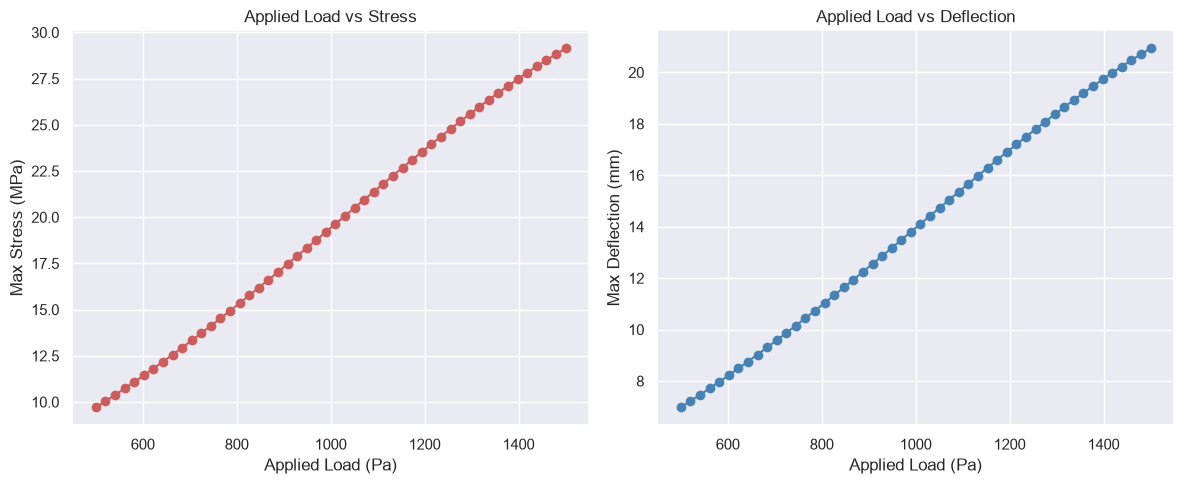

In [10]:
# Plot - Load vs Stress and Deflection using src visualization
plot_parameter_sweep(
    loads_dense, s3_stress / 1e6, s3_defl * 1000,
    xlabel="Applied Load (Pa)",
    title_prefix="Applied Load"
)
plt.show()


## 4. Material Comparison
Since materials are categorical (one-hot encoded), we sweep them discretely (it is not physically meaningful to interpolate between materials).


In [11]:
# Sweep - Material (blade=1.2m, chord=150mm, load=1000Pa)
materials = ["Aluminium", "Fiberglass", "Carbon fiber"]
fixed4 = {"blade_length": 1.2, "chord": 150, "material": None, "load": 1000}

mat_stress, mat_defl = sweep(stress_model, deflection_model, X_encoded.columns, "material", materials, fixed4)

print("Material Sweeps calculated.")
print("Material choices:", materials)
print("Stress (MPa):", np.round(mat_stress / 1e6, 3))
print("Deflection (mm):", np.round(mat_defl / 0.001, 3))


Material Sweeps calculated.
Material choices: ['Aluminium', 'Fiberglass', 'Carbon fiber']
Stress (MPa): [19.42  19.425 19.422]
Deflection (mm): [24.252 67.022 13.953]


## 5. Parameter Importance Ranking
We calculate the maximum-to-minimum ratios from the sweeps to determine which parameters exert the strongest influence on Stress and Deflection.


In [12]:
# Parameter influence ranking - based on max/min ratio across each sweep (evaluated dense curves)
ranking_df = pd.DataFrame([
    {"Parameter": "Blade Length", "Stress Ratio (max/min)": ratio(s1_stress), "Deflection Ratio (max/min)": ratio(s1_defl)},
    {"Parameter": "Chord Length", "Stress Ratio (max/min)": ratio(s2_stress), "Deflection Ratio (max/min)": ratio(s2_defl)},
    {"Parameter": "Applied Load", "Stress Ratio (max/min)": ratio(s3_stress), "Deflection Ratio (max/min)": ratio(s3_defl)},
    {"Parameter": "Material", "Stress Ratio (max/min)": ratio(mat_stress), "Deflection Ratio (max/min)": ratio(mat_defl)},
])
ranking_df


,Parameter,Stress Ratio (max/min),Deflection Ratio (max/min)
0,Blade Length,4.016877,15.587392
1,Chord Length,4.021215,7.432019
2,Applied Load,2.999970,3.000027
3,Material,1.000261,4.803373
